# v4 Dataset vs. Original: Year-Holdout CV Comparison

The **v4 build** (see CLAUDE.md, "Full-scale build v4") added every remaining quiet date
to the original v2 run set (4,919 completed runs vs. 3,183), then re-ran the same 12-fold
leave-one-year-out CV with the identical recipe (`TornadoUNet(base_channels=16)`, alpha=0.25,
gamma=2.0, 50 epochs, seed=0, 14 features -- the 7 UH columns dropped).

**The catch this notebook is built around:** the two CVs' headline AUC-PR numbers are measured on
*different test sets*. v4's held-out years contain many extra quiet maps, which lowers the per-cell
positive rate (by ~34% on average) and can lower AUC-PR / F1 even for an identical model. So a naive
"old AUC-PR vs. new AUC-PR" comparison is not like-for-like. Three comparisons below:

1. **As-reported** -- each CV's own numbers, each on its own test set (confounded).
2. **Like-for-like, full v4 test year** -- *both* sets of fold checkpoints scored on the *same* v4 held-out samples.
3. **Like-for-like, old-run subset** -- both scored on only the v4 held-out samples whose run was in the original v2 set (the original test distribution).

Like-for-like numbers come from `scripts/compare_cv_old_vs_v4.py` (inference only, no retraining).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd().parent
OLD_PATH = REPO_ROOT / "models" / "cv_year_holdout" / "results.json"
NEW_PATH = REPO_ROOT / "models" / "cv_year_holdout_v4" / "results.json"
L4L_PATH = REPO_ROOT / "models" / "cv_year_holdout_v4" / "like_for_like.json"

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"
C_OLD, C_NEW = "#7fb3d5", "#f5b041"

old = {f["held_out_year"]: f for f in json.loads(OLD_PATH.read_text())["folds"]}
new = {f["held_out_year"]: f for f in json.loads(NEW_PATH.read_text())["folds"]}
l4l = {f["held_out_year"]: f for f in json.loads(L4L_PATH.read_text())["folds"]}
years = sorted(set(old) & set(new) & set(l4l))
print(f"{len(years)} folds: {years}")

12 folds: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. As-reported (each CV on its own test set)

Training set grew from ~3.2k to ~4.9k runs; test-year positive rate drops because of the added quiet maps.

In [2]:
rows = []
for y in years:
    o, n = old[y], new[y]
    rows.append({
        "year": y,
        "n_test_old": o["n_test"], "n_test_v4": n["n_test"],
        "pos_rate_old": o["pos_rate"], "pos_rate_v4": n["pos_rate"],
        "auc_pr_old": o["auc_pr"], "auc_pr_v4": n["auc_pr"],
        "auc_pr_change_%": 100 * (n["auc_pr"] / o["auc_pr"] - 1),
        "lift_old": o["auc_pr"] / o["pos_rate"], "lift_v4": n["auc_pr"] / n["pos_rate"],
        "f1_old": o["f1_at_best_f1"], "f1_v4": n["f1_at_best_f1"],
    })
asrep = pd.DataFrame(rows)
asrep.round(5)

,year,n_test_old,n_test_v4,pos_rate_old,pos_rate_v4,auc_pr_old,auc_pr_v4,auc_pr_change_%,lift_old,lift_v4,f1_old,f1_v4
0,2014,88,208,0.00015,0.00007,0.03141,0.02851,-9.23455,205.97846,414.28033,0.08000,0.08864
1,2015,528,860,0.00020,0.00013,0.02760,0.02573,-6.76987,138.49930,197.54742,0.07192,0.08077
2,2016,484,782,0.00018,0.00011,0.03088,0.03663,18.60427,175.31850,328.38080,0.09174,0.10264
3,2017,582,866,0.00024,0.00016,0.04663,0.04437,-4.85466,195.21969,271.31647,0.11123,0.11007
4,2018,524,870,0.00019,0.00012,0.04268,0.03525,-17.39575,227.05219,287.14355,0.11241,0.10284
5,2019,644,934,0.00022,0.00016,0.03617,0.02873,-20.57018,165.00640,182.78636,0.09467,0.07870
6,2020,524,876,0.00020,0.00013,0.05539,0.03871,-30.11653,282.87326,308.42581,0.13155,0.10804
7,2021,572,912,0.00022,0.00015,0.04472,0.04786,7.02536,199.12960,329.47366,0.11427,0.11514
8,2022,564,888,0.00021,0.00014,0.07403,0.06297,-14.94544,352.23569,465.72353,0.16892,0.15248
9,2023,616,920,0.00020,0.00014,0.05264,0.04835,-8.15442,259.46461,350.39470,0.12451,0.12493


In [3]:
def summ(a):
    a = np.asarray(a)
    return f"{a.mean():.4f} +/- {a.std():.4f}"

print("AS-REPORTED (different test sets -- confounded)")
print(f"  AUC-PR  old: {summ(asrep.auc_pr_old)}   v4: {summ(asrep.auc_pr_v4)}")
print(f"  best F1 old: {summ(asrep.f1_old)}   v4: {summ(asrep.f1_v4)}")
print(f"  lift    old: {asrep.lift_old.mean():.0f}x   v4: {asrep.lift_v4.mean():.0f}x   (lift = AUC-PR / positive rate)")
print(f"  v4 wins AUC-PR in {(asrep.auc_pr_v4 > asrep.auc_pr_old).sum()} of {len(asrep)} folds")

AS-REPORTED (different test sets -- confounded)
  AUC-PR  old: 0.0486 +/- 0.0180   v4: 0.0442 +/- 0.0142
  best F1 old: 0.1171 +/- 0.0317   v4: 0.1148 +/- 0.0269
  lift    old: 230x   v4: 322x   (lift = AUC-PR / positive rate)
  v4 wins AUC-PR in 3 of 12 folds


## 2. Like-for-like: both model sets on the *same* test samples

For each held-out year, the old fold checkpoint and the v4 fold checkpoint are both scored on identical
samples. Any difference here is the models, not the test set.

In [4]:
def l4l_frame(subset):
    rows = []
    for y in years:
        o, n = l4l[y]["old_model"][subset], l4l[y]["v4_model"][subset]
        rows.append({
            "year": y, "n_samples": o["n_samples"], "n_active": o["n_active"], "pos_rate": o["pos_rate"],
            "auc_pr_old": o["auc_pr"], "auc_pr_v4": n["auc_pr"],
            "auc_pr_change_%": 100 * (n["auc_pr"] / o["auc_pr"] - 1),
            "f1_old": o["f1_at_best_f1"], "f1_v4": n["f1_at_best_f1"],
            "prec_old": o["precision_at_best_f1"], "prec_v4": n["precision_at_best_f1"],
            "rec_old": o["recall_at_best_f1"], "rec_v4": n["recall_at_best_f1"],
            "thr_old": o["best_f1_threshold"], "thr_v4": n["best_f1_threshold"],
            "roc_old": o["auc_roc"], "roc_v4": n["auc_roc"],
            "mean_neg_p_old": o["mean_proba_negative"], "mean_neg_p_v4": n["mean_proba_negative"],
            "mean_pos_p_old": o["mean_proba_positive"], "mean_pos_p_v4": n["mean_proba_positive"],
        })
    return pd.DataFrame(rows)

full = l4l_frame("full_v4")
full.round(5)

,year,n_samples,n_active,pos_rate,auc_pr_old,auc_pr_v4,auc_pr_change_%,f1_old,f1_v4,prec_old,...,rec_old,rec_v4,thr_old,thr_v4,roc_old,roc_v4,mean_neg_p_old,mean_neg_p_v4,mean_pos_p_old,mean_pos_p_v4
0,2014,208,51,0.00007,0.02763,0.02851,3.17235,0.07345,0.08864,0.06701,...,0.08125,0.20000,0.22366,0.19038,0.99116,0.99391,0.00717,0.01380,0.14049,0.13291
1,2015,860,359,0.00013,0.02771,0.02573,-7.14458,0.07423,0.08077,0.06658,...,0.08387,0.10783,0.22838,0.20909,0.98084,0.98391,0.00313,0.00629,0.10483,0.11323
2,2016,782,311,0.00011,0.02746,0.03663,33.38790,0.08660,0.10264,0.06512,...,0.12923,0.17744,0.23165,0.20159,0.97867,0.98761,0.00801,0.00640,0.13501,0.13085
3,2017,866,403,0.00016,0.04369,0.04437,1.56364,0.10595,0.11007,0.08217,...,0.14908,0.25584,0.21938,0.20943,0.99095,0.99216,0.00407,0.00732,0.13689,0.15508
4,2018,870,378,0.00012,0.03786,0.03525,-6.88356,0.10561,0.10284,0.07577,...,0.17420,0.16248,0.19957,0.21733,0.98998,0.98665,0.00596,0.00614,0.14119,0.13576
5,2019,934,437,0.00016,0.03388,0.02873,-15.19763,0.09126,0.07870,0.06314,...,0.16453,0.21085,0.20000,0.19980,0.98820,0.98697,0.01129,0.00939,0.13918,0.13328
6,2020,876,348,0.00013,0.05248,0.03871,-26.23914,0.13083,0.10804,0.10229,...,0.18145,0.13344,0.22422,0.20014,0.99009,0.98473,0.00579,0.00955,0.13835,0.12540
7,2021,912,391,0.00015,0.04144,0.04786,15.51066,0.10988,0.11514,0.07889,...,0.18096,0.22080,0.19253,0.19551,0.99060,0.99279,0.01100,0.00753,0.13546,0.13552
8,2022,888,355,0.00014,0.07230,0.06297,-12.91150,0.16805,0.15248,0.13630,...,0.21908,0.21759,0.22049,0.22491,0.99112,0.99151,0.00808,0.00600,0.15184,0.15215
9,2023,920,397,0.00014,0.05115,0.04835,-5.48337,0.12261,0.12493,0.08783,...,0.20296,0.14940,0.19961,0.20897,0.99018,0.98941,0.00709,0.00509,0.13793,0.12052


In [5]:
def paired(df, a, b, label):
    d = df[b] - df[a]
    t, p = stats.ttest_rel(df[b], df[a])
    try:
        w = stats.wilcoxon(df[b], df[a]).pvalue
    except ValueError:
        w = float("nan")
    print(f"{label:12s} old {df[a].mean():.4f} -> v4 {df[b].mean():.4f}  "
          f"(mean diff {d.mean():+.4f}, {100*d.mean()/df[a].mean():+.1f}%)  "
          f"v4 wins {(d > 0).sum()}/{len(d)}  paired-t p={p:.3f}  wilcoxon p={w:.3f}")

print("LIKE-FOR-LIKE, full v4 test years")
paired(full, "auc_pr_old", "auc_pr_v4", "AUC-PR")
paired(full, "f1_old", "f1_v4", "best F1")
paired(full, "roc_old", "roc_v4", "AUC-ROC")

LIKE-FOR-LIKE, full v4 test years
AUC-PR       old 0.0461 -> v4 0.0442  (mean diff -0.0019, -4.0%)  v4 wins 5/12  paired-t p=0.539  wilcoxon p=0.470
best F1      old 0.1141 -> v4 0.1148  (mean diff +0.0006, +0.6%)  v4 wins 7/12  paired-t p=0.890  wilcoxon p=0.910
AUC-ROC      old 0.9880 -> v4 0.9894  (mean diff +0.0013, +0.1%)  v4 wins 7/12  paired-t p=0.294  wilcoxon p=0.424


## 3. Like-for-like on the original test distribution (old-run subset)

Only the v4 held-out samples whose run was already in the original v2 run set -- i.e. roughly the test
distribution the original CV was scored on (it differs slightly: the original CV's buffer/test membership
was computed on the v2 run set alone). This isolates "did the extra quiet *training* data help on the
*original-style* test data?" from the harder, quieter v4 test mix.

In [6]:
sub = l4l_frame("old_subset")
sub.round(5)

,year,n_samples,n_active,pos_rate,auc_pr_old,auc_pr_v4,auc_pr_change_%,f1_old,f1_v4,prec_old,...,rec_old,rec_v4,thr_old,thr_v4,roc_old,roc_v4,mean_neg_p_old,mean_neg_p_v4,mean_pos_p_old,mean_pos_p_v4
0,2014,88,48,0.00015,0.03141,0.03342,6.38895,0.08000,0.09861,0.04545,...,0.33333,0.21333,0.18180,0.19038,0.98814,0.99010,0.00794,0.01496,0.13965,0.13342
1,2015,528,340,0.00020,0.02760,0.02637,-4.45426,0.07192,0.08259,0.06480,...,0.08078,0.11054,0.22838,0.20914,0.97735,0.97942,0.00365,0.00735,0.10399,0.11308
2,2016,484,296,0.00018,0.03088,0.03906,26.47882,0.09174,0.10597,0.07023,...,0.13221,0.18153,0.23165,0.20159,0.97649,0.98500,0.00872,0.00740,0.13623,0.13205
3,2017,582,391,0.00024,0.04663,0.04694,0.66035,0.11123,0.11391,0.06956,...,0.27735,0.25869,0.19166,0.20943,0.98959,0.99079,0.00450,0.00799,0.13704,0.15563
4,2018,524,336,0.00019,0.04268,0.03883,-9.00786,0.11241,0.10682,0.08103,...,0.18347,0.16712,0.19957,0.21733,0.98874,0.98526,0.00680,0.00689,0.14354,0.13732
5,2019,644,415,0.00022,0.03617,0.03128,-13.52511,0.09467,0.08320,0.06553,...,0.17047,0.21926,0.20000,0.19852,0.98680,0.98562,0.01206,0.01015,0.14041,0.13452
6,2020,524,323,0.00020,0.05539,0.04198,-24.21020,0.13155,0.11330,0.10499,...,0.17611,0.13514,0.22422,0.20014,0.98789,0.98105,0.00647,0.01058,0.13744,0.12456
7,2021,572,366,0.00022,0.04472,0.05112,14.30389,0.11427,0.11885,0.08248,...,0.18593,0.22632,0.19253,0.19551,0.98946,0.99185,0.01207,0.00801,0.13675,0.13705
8,2022,562,345,0.00021,0.07403,0.06499,-12.21330,0.16892,0.15364,0.13666,...,0.22113,0.21962,0.22049,0.22491,0.99022,0.99053,0.00837,0.00630,0.15237,0.15254
9,2023,616,386,0.00020,0.05264,0.05000,-5.02640,0.12451,0.12696,0.08932,...,0.20544,0.15104,0.19961,0.20897,0.98792,0.98680,0.00792,0.00584,0.13820,0.12073


In [7]:
def paired(df, a, b, label):
    d = df[b] - df[a]
    t, p = stats.ttest_rel(df[b], df[a])
    try:
        w = stats.wilcoxon(df[b], df[a]).pvalue
    except ValueError:
        w = float("nan")
    print(f"{label:12s} old {df[a].mean():.4f} -> v4 {df[b].mean():.4f}  "
          f"(mean diff {d.mean():+.4f}, {100*d.mean()/df[a].mean():+.1f}%)  "
          f"v4 wins {(d > 0).sum()}/{len(d)}  paired-t p={p:.3f}  wilcoxon p={w:.3f}")

print("LIKE-FOR-LIKE, old-run subset of each held-out year")
paired(sub, "auc_pr_old", "auc_pr_v4", "AUC-PR")
paired(sub, "f1_old", "f1_v4", "best F1")
paired(sub, "roc_old", "roc_v4", "AUC-ROC")

LIKE-FOR-LIKE, old-run subset of each held-out year
AUC-PR       old 0.0486 -> v4 0.0468  (mean diff -0.0018, -3.7%)  v4 wins 5/12  paired-t p=0.545  wilcoxon p=0.519
best F1      old 0.1171 -> v4 0.1184  (mean diff +0.0013, +1.1%)  v4 wins 7/12  paired-t p=0.776  wilcoxon p=0.910
AUC-ROC      old 0.9862 -> v4 0.9873  (mean diff +0.0010, +0.1%)  v4 wins 7/12  paired-t p=0.438  wilcoxon p=0.424


## 4. Precision and recall (at each model's best-F1 threshold)

AUC-PR summarizes the whole precision-recall curve; precision and recall at the best-F1 operating point say
what a forecaster would actually see: **recall** = fraction of true tornado-affected cells the model flags,
**precision** = fraction of flagged cells that really are tornado-affected. F1 is their harmonic mean.

Caveat: each model uses *its own* best-F1 threshold (chosen on the same data it is scored on), so the two
models are compared at *different* operating points, not at matched recall or matched precision. A shift
along the precision-recall curve (more recall, less precision) is not an improvement in ranking quality --
AUC-PR is the matched-threshold-free measure for that. Thresholds are shown so any shift is visible.

In [8]:
pr_asrep = pd.DataFrame({
    "year": years,
    "prec_old": [old[y]["precision_at_best_f1"] for y in years],
    "prec_v4": [new[y]["precision_at_best_f1"] for y in years],
    "rec_old": [old[y]["recall_at_best_f1"] for y in years],
    "rec_v4": [new[y]["recall_at_best_f1"] for y in years],
    "thr_old": [old[y]["best_f1_threshold"] for y in years],
    "thr_v4": [new[y]["best_f1_threshold"] for y in years],
})
print("AS-REPORTED (each CV on its own test set)")
paired(pr_asrep, "prec_old", "prec_v4", "precision")
paired(pr_asrep, "rec_old", "rec_v4", "recall")
paired(pr_asrep, "thr_old", "thr_v4", "threshold")
print()
print("LIKE-FOR-LIKE, full v4 test years")
paired(full, "prec_old", "prec_v4", "precision")
paired(full, "rec_old", "rec_v4", "recall")
paired(full, "thr_old", "thr_v4", "threshold")
print()
print("LIKE-FOR-LIKE, old-run subset")
paired(sub, "prec_old", "prec_v4", "precision")
paired(sub, "rec_old", "rec_v4", "recall")
paired(sub, "thr_old", "thr_v4", "threshold")

AS-REPORTED (each CV on its own test set)
precision    old 0.0886 -> v4 0.0841  (mean diff -0.0045, -5.0%)  v4 wins 5/12  paired-t p=0.356  wilcoxon p=0.470
recall       old 0.1968 -> v4 0.1946  (mean diff -0.0022, -1.1%)  v4 wins 6/12  paired-t p=0.897  wilcoxon p=0.850
threshold    old 0.2065 -> v4 0.2073  (mean diff +0.0009, +0.4%)  v4 wins 8/12  paired-t p=0.864  wilcoxon p=0.677

LIKE-FOR-LIKE, full v4 test years
precision    old 0.0905 -> v4 0.0841  (mean diff -0.0064, -7.1%)  v4 wins 3/12  paired-t p=0.246  wilcoxon p=0.266
recall       old 0.1621 -> v4 0.1946  (mean diff +0.0325, +20.1%)  v4 wins 8/12  paired-t p=0.061  wilcoxon p=0.092
threshold    old 0.2125 -> v4 0.2073  (mean diff -0.0052, -2.4%)  v4 wins 6/12  paired-t p=0.341  wilcoxon p=0.519

LIKE-FOR-LIKE, old-run subset
precision    old 0.0886 -> v4 0.0872  (mean diff -0.0014, -1.6%)  v4 wins 6/12  paired-t p=0.771  wilcoxon p=1.000
recall       old 0.1968 -> v4 0.1986  (mean diff +0.0018, +0.9%)  v4 wins 6/12  paired

In [9]:
display(full[["year", "prec_old", "prec_v4", "rec_old", "rec_v4", "thr_old", "thr_v4", "f1_old", "f1_v4"]].round(3))

,year,prec_old,prec_v4,rec_old,rec_v4,thr_old,thr_v4,f1_old,f1_v4
0,2014,0.067,0.057,0.081,0.200,0.224,0.190,0.073,0.089
1,2015,0.067,0.065,0.084,0.108,0.228,0.209,0.074,0.081
2,2016,0.065,0.072,0.129,0.177,0.232,0.202,0.087,0.103
3,2017,0.082,0.070,0.149,0.256,0.219,0.209,0.106,0.110
4,2018,0.076,0.075,0.174,0.162,0.200,0.217,0.106,0.103
5,2019,0.063,0.048,0.165,0.211,0.200,0.200,0.091,0.079
6,2020,0.102,0.091,0.181,0.133,0.224,0.200,0.131,0.108
7,2021,0.079,0.078,0.181,0.221,0.193,0.196,0.110,0.115
8,2022,0.136,0.117,0.219,0.218,0.220,0.225,0.168,0.152
9,2023,0.088,0.107,0.203,0.149,0.200,0.209,0.123,0.125


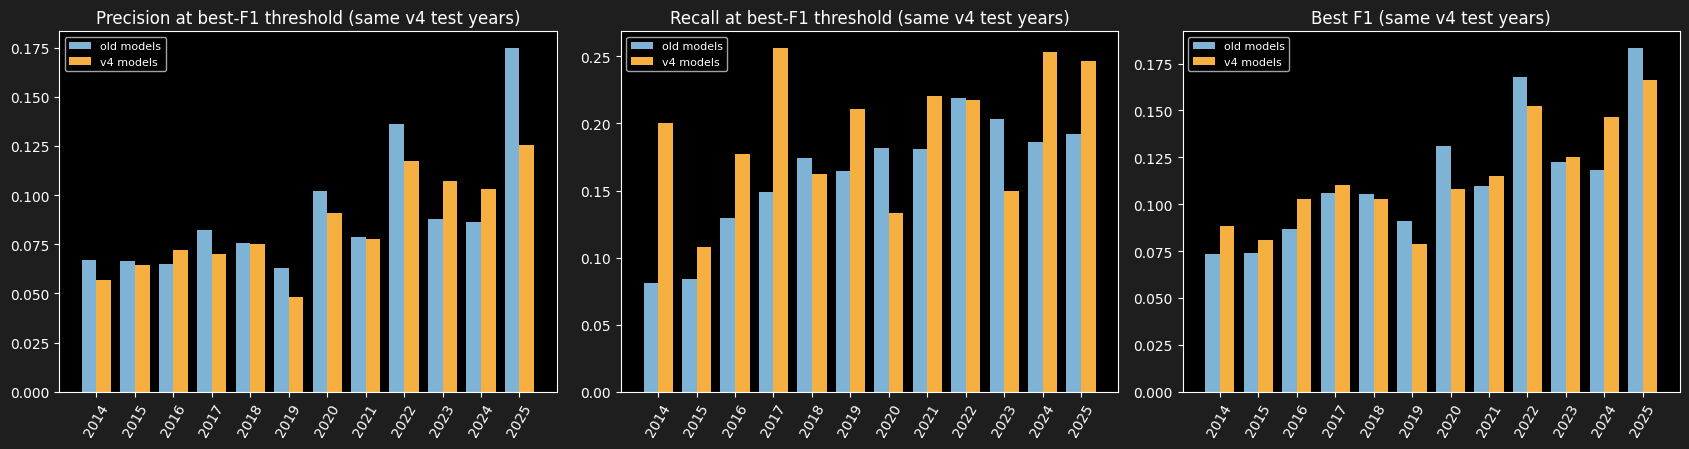

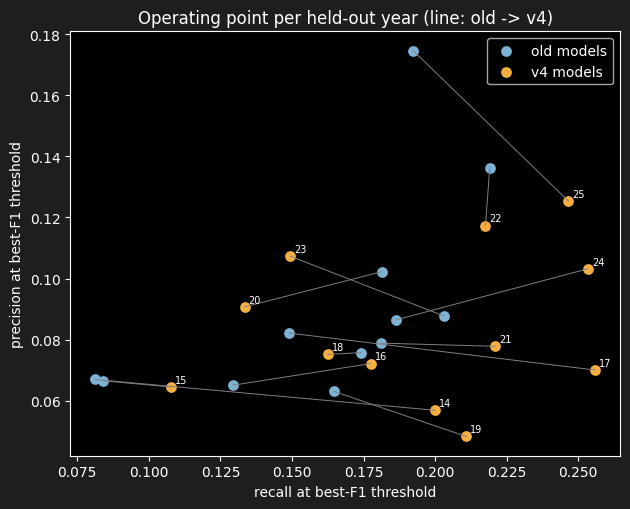

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
x = np.arange(len(years)); w = 0.38
for ax, (a, b, title) in zip(axes, (
    ("prec_old", "prec_v4", "Precision at best-F1 threshold"),
    ("rec_old", "rec_v4", "Recall at best-F1 threshold"),
    ("f1_old", "f1_v4", "Best F1"),
)):
    ax.bar(x - w/2, full[a], w, color=C_OLD, label="old models")
    ax.bar(x + w/2, full[b], w, color=C_NEW, label="v4 models")
    ax.set_title(title + " (same v4 test years)")
    ax.set_xticks(x); ax.set_xticklabels(years, rotation=60); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(full.rec_old, full.prec_old, color=C_OLD, label="old models", s=45)
ax.scatter(full.rec_v4, full.prec_v4, color=C_NEW, label="v4 models", s=45)
for _, r in full.iterrows():
    ax.plot([r.rec_old, r.rec_v4], [r.prec_old, r.prec_v4], color="gray", lw=0.7)
    ax.annotate(str(int(r.year))[2:], (r.rec_v4, r.prec_v4), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("recall at best-F1 threshold"); ax.set_ylabel("precision at best-F1 threshold")
ax.set_title("Operating point per held-out year (line: old -> v4)")
ax.legend(); plt.tight_layout(); plt.show()

## Visual comparison

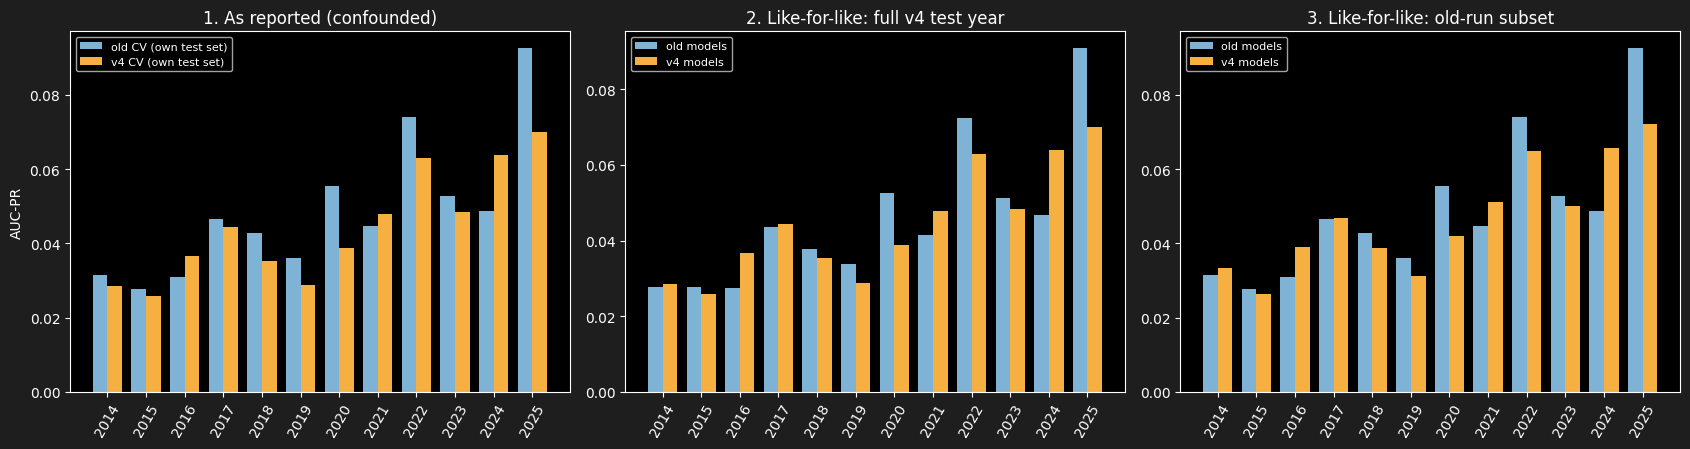

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharey=False)
x = np.arange(len(years)); w = 0.38

ax = axes[0]
ax.bar(x - w/2, asrep.auc_pr_old, w, color=C_OLD, label="old CV (own test set)")
ax.bar(x + w/2, asrep.auc_pr_v4, w, color=C_NEW, label="v4 CV (own test set)")
ax.set_title("1. As reported (confounded)"); ax.set_ylabel("AUC-PR")

ax = axes[1]
ax.bar(x - w/2, full.auc_pr_old, w, color=C_OLD, label="old models")
ax.bar(x + w/2, full.auc_pr_v4, w, color=C_NEW, label="v4 models")
ax.set_title("2. Like-for-like: full v4 test year")

ax = axes[2]
ax.bar(x - w/2, sub.auc_pr_old, w, color=C_OLD, label="old models")
ax.bar(x + w/2, sub.auc_pr_v4, w, color=C_NEW, label="v4 models")
ax.set_title("3. Like-for-like: old-run subset")

for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(years, rotation=60)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

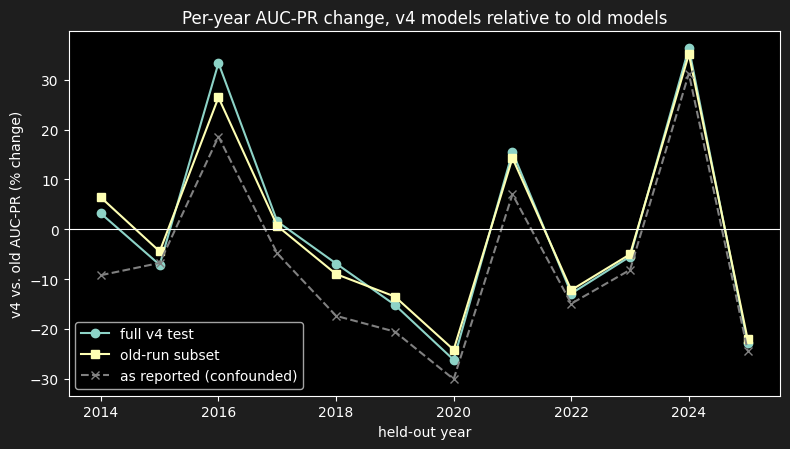

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for df, lab, mk in ((full, "full v4 test", "o"), (sub, "old-run subset", "s")):
    ax.plot(df.year, df["auc_pr_change_%"], marker=mk, label=lab)
ax.plot(asrep.year, asrep["auc_pr_change_%"], marker="x", ls="--", color="gray", label="as reported (confounded)")
ax.axhline(0, color="white", lw=0.8)
ax.set_ylabel("v4 vs. old AUC-PR (% change)"); ax.set_xlabel("held-out year")
ax.set_title("Per-year AUC-PR change, v4 models relative to old models")
ax.legend(); plt.tight_layout(); plt.show()

## Does the base-rate effect explain the as-reported gap?

If the extra quiet maps merely lowered the base rate, the *old* models scored on the full v4 test years should
also drop relative to their original scores. Comparing the old models' AUC-PR on their own original test set vs.
on the full v4 test year measures that effect directly, with the model held fixed.

In [13]:
eff = pd.DataFrame({
    "year": years,
    "old_model_on_old_test": [old[y]["auc_pr"] for y in years],
    "old_model_on_v4_full_test": [l4l[y]["old_model"]["full_v4"]["auc_pr"] for y in years],
    "pos_rate_old_test": [old[y]["pos_rate"] for y in years],
    "pos_rate_v4_test": [l4l[y]["old_model"]["full_v4"]["pos_rate"] for y in years],
})
eff["test_set_effect_%"] = 100 * (eff.old_model_on_v4_full_test / eff.old_model_on_old_test - 1)
display(eff.round(5))
print(f"Mean test-set effect on AUC-PR with the model held fixed: {eff['test_set_effect_%'].mean():+.1f}%")
print(f"Mean positive-rate ratio (v4 test / old test): {(eff.pos_rate_v4_test / eff.pos_rate_old_test).mean():.2f}")

,year,old_model_on_old_test,old_model_on_v4_full_test,pos_rate_old_test,pos_rate_v4_test,test_set_effect_%
0,2014,0.03141,0.02763,0.00015,0.00007,-12.02541
1,2015,0.02760,0.02771,0.00020,0.00013,0.40354
2,2016,0.03088,0.02746,0.00018,0.00011,-11.08318
3,2017,0.04663,0.04369,0.00024,0.00016,-6.31948
4,2018,0.04268,0.03786,0.00019,0.00012,-11.28929
5,2019,0.03617,0.03388,0.00022,0.00016,-6.33537
6,2020,0.05539,0.05248,0.00020,0.00013,-5.25671
7,2021,0.04472,0.04144,0.00022,0.00015,-7.34590
8,2022,0.07403,0.07230,0.00021,0.00014,-2.33549
9,2023,0.05264,0.05115,0.00020,0.00014,-2.82601


Mean test-set effect on AUC-PR with the model held fixed: -5.8%
Mean positive-rate ratio (v4 test / old test): 0.66


## Calendar-year trend (does the earlier r=0.79 finding persist?)

In [14]:
for label, vals in (
    ("old CV (as reported)", asrep.auc_pr_old),
    ("v4 CV (as reported)", asrep.auc_pr_v4),
    ("old models, full v4 test", full.auc_pr_old),
    ("v4 models, full v4 test", full.auc_pr_v4),
):
    r, p = stats.pearsonr(years, vals)
    print(f"{label:28s} Pearson r vs. year = {r:+.2f} (p={p:.3f})   mean 2020-25 {np.mean([v for y, v in zip(years, vals) if y >= 2020]):.4f}"
          f" vs 2015-19 {np.mean([v for y, v in zip(years, vals) if 2015 <= y <= 2019]):.4f}")

old CV (as reported)         Pearson r vs. year = +0.79 (p=0.002)   mean 2020-25 0.0613 vs 2015-19 0.0368
v4 CV (as reported)          Pearson r vs. year = +0.87 (p=0.000)   mean 2020-25 0.0553 vs 2015-19 0.0341
old models, full v4 test     Pearson r vs. year = +0.79 (p=0.002)   mean 2020-25 0.0592 vs 2015-19 0.0341
v4 models, full v4 test      Pearson r vs. year = +0.87 (p=0.000)   mean 2020-25 0.0553 vs 2015-19 0.0341


## Conclusions

**Verdict: v4 is statistically indistinguishable from the original -- not better, not worse.** (All figures below are from the cells above; 12 folds.)

| comparison | AUC-PR old | AUC-PR v4 | change | v4 wins | paired-t p |
|---|---|---|---|---|---|
| As reported (different test sets) | 0.0486 +/- 0.0180 | 0.0442 +/- 0.0142 | -9.0% | 3/12 | 0.16 |
| **Like-for-like, full v4 test years** | 0.0461 +/- 0.0183 | 0.0442 +/- 0.0142 | **-4.0%** | 5/12 | 0.54 |
| **Like-for-like, old-run subset** | 0.0486 +/- 0.0180 | 0.0468 +/- 0.0140 | **-3.7%** | 5/12 | 0.55 |

- **Like-for-like AUC-PR is ~4% lower for v4, well inside the noise** (paired-t p ~ 0.54, Wilcoxon p ~ 0.47-0.52; v4 wins 5 of 12 folds). Best-F1 is flat (+0.6% / +1.1%, 7 of 12 wins, p ~ 0.8-0.9); AUC-ROC is flat (+0.1%). No metric moves anywhere near significance.
- **Per-fold results swing hard in both directions** with no consistent winner: v4 is much better in 2016 (+33%) and 2024 (+36%) and much worse in 2020 (-26%), 2025 (-23%) and 2019 (-15%). A 12-fold, single-seed comparison can't resolve a +/-4% mean difference against swings of +/-25%.
- **Sanity check that the like-for-like pipeline is sound:** the old models scored on the old-run subset reproduce the original CV's AUC-PR to within 5e-7 in every fold, so the old-vs-v4 comparison on that subset is genuinely the same test distribution.
- **Correction to an earlier hypothesis:** I expected the added quiet maps to mechanically depress AUC-PR through the lower base rate. Holding the *old model fixed*, moving from its original test set to the full v4 test years (positive rate down ~34%) only lowers AUC-PR by about 6% -- a real but small effect. So most of the as-reported -9% is the models themselves (about -4%) plus a small test-set effect (about -6%, partially offset in the fold-level mix), not a large base-rate artifact. The extra quiet maps are mostly easy true-negatives.
- **Calibration is essentially unchanged:** mean positive-cell probability is identical (0.1365 vs 0.1364) and mean negative-cell probability only slightly higher for v4 (0.0071 -> 0.0076). The extra quiet training data did not visibly change how the model scores cells.
- **Possible but unproven upside:** v4's across-fold spread is smaller (std 0.0142 vs 0.0183 on the as-reported/full-test comparison). With 12 folds and one seed per fold I would not call this a real variance reduction.
- **The calendar-year skill trend persists and is, if anything, stronger:** Pearson r vs. year is 0.79 (p = 0.002) for the old models and 0.87 (p < 0.001) for v4; 2020-25 vs. 2015-19 mean AUC-PR is 0.0613 vs. 0.0368 (old) and 0.0553 vs. 0.0341 (v4). Both model sets show it, on the same test samples, so it is a property of the data/HRRR vintage, not of either training set. This is still unexplained (HRRR model upgrades remain the leading hypothesis).

**What this does and doesn't tell us**
- Adding ~1,700 quiet-date runs (3,183 -> 4,919 total) to training did **not** produce a measurable gain at this model size and recipe. The 14-feature U-Net still performs at AUC-PR ~ 0.045-0.049 across CV.
- It also did not hurt: the larger, more representative negative set costs nothing detectable in ranking quality, and the dataset is now closer to the natural class balance (~44% active maps vs. ~63%), which matters if the model is ever run on a real, mostly-quiet forecast stream.
- Not tested: quiet-map downsampling (`quiet_keep_fraction=0.2`) means the model sees only ~20% of the new quiet maps each epoch, so the effective training change may be much smaller than the 55% larger dataset suggests. Raising `quiet_keep_fraction`, or changing the recipe (alpha, epochs) now that there is more data, were not tried here.
- Single seed per fold throughout. The old CV and v4 CV each trained once per year; seed-to-seed variance has never been measured in this project and could be a meaningful part of the fold-level swings.

**Precision and recall (at each model's own best-F1 threshold, section 4)**

| comparison | metric | old | v4 | change | v4 wins | paired-t p |
|---|---|---|---|---|---|---|
| Like-for-like, full v4 test years | precision | 0.0905 | 0.0841 | -7.1% | 3/12 | 0.25 |
| | recall | 0.1621 | 0.1946 | **+20.1%** | 8/12 | 0.061 |
| Like-for-like, old-run subset | precision | 0.0886 | 0.0872 | -1.6% | 6/12 | 0.77 |
| | recall | 0.1968 | 0.1986 | +0.9% | 6/12 | 0.91 |
| As reported | precision | 0.0886 | 0.0841 | -5.0% | 5/12 | 0.36 |
| | recall | 0.1968 | 0.1946 | -1.1% | 6/12 | 0.90 |

- **At the best-F1 operating point the model flags roughly 1 in 5 tornado-affected cells (recall ~0.19-0.20) with ~9% precision** -- i.e. about 10 flagged cells per true hit. Same story for old and v4 on the original test distribution (old-run subset): precision and recall differ by 1-2%, p > 0.7.
- **The one notable movement is recall on the full v4 test years: +20% (0.162 -> 0.195), 8/12 wins, p = 0.061 -- suggestive, not significant**, and paired with a precision dip (-7%, p = 0.25). Read it cautiously: the *old* models' recall falls from 0.197 to 0.162 when moved from their original test set to the full v4 test years (their best-F1 threshold shifts in response to the extra quiet maps), while v4 models hold steady at ~0.195 on both. That is consistent with v4 models being somewhat more robust to the quieter test mix, but it is a threshold-dependent, operating-point effect, and AUC-PR (the matched-threshold-free metric) shows no corresponding gain.
- **Best-F1 thresholds are essentially identical (~0.21 for both)** and far below 0.5, as established earlier -- 0.5 remains unusable as an operating threshold for this model family.
- **Treat precision/recall here as descriptive, not as an independent test:** each model's threshold is tuned on the same test data it is scored on (optimistic for both equally), and the two models are not compared at matched recall or precision. A matched-recall precision comparison (precision at a fixed recall, e.g. 0.2) from the full PR curves would be the cleaner operating-point test; not done here.
